In [1]:
import numpy as np
from pyhdf import SD
import matplotlib.pyplot as plt
import glob

In [2]:
#Create a MODIS data class using pyhdf to access the data
class MODIS_Aerosol(object):
    def __init__(self,fn):
        hdf = SD.SD(fn)
        self.AOD550=hdf.select("Deep_Blue_Aerosol_Optical_Depth_550_Land_Best_Estimate")
        self.AODuncert=hdf.select("Deep_Blue_Aerosol_Optical_Depth_550_Land_Estimated_Uncertainty")
        self.data=[]
        for k in hdf.datasets():
            self.data.append(k)
        hdf.end()

In [3]:
#set a specific modis file to be analyzed (file downloaded from nasa earth data search, product:MODIS/Terra Aerosol 5-Min L2 Swath 10km)
data_path='/home/jmelles1/zzbatmos_user/EMIT_DATA/EMIT_CERES_data/'
MODIS_data=MODIS_Aerosol(data_path+"MOD04_L2.A2023095.0915.061.2023134031753.hdf")

In [13]:
file=SD.SD(data_path+"MOD04_L2.A2023095.0915.061.2023134031753.hdf",SD.SDC.READ)
sds_obj = file.select("Deep_Blue_Aerosol_Optical_Depth_550_Land_Best_Estimate")
lat_obj=file.select("Latitude")
lon_obj=file.select("Longitude")
type_obj=file.select("Aerosol_Type_Land")
AOD = sds_obj.get()

Lat=lat_obj.get()
Lon=lon_obj.get()
print ("AOD array:",AOD)
print ("Latitude array:",Lat)
print ("Longitude array:",Lon)

AOD array: [[   49    41   126 ... -9999 -9999 -9999]
 [   28    29    95 ... -9999 -9999 -9999]
 [   17    37    99 ... -9999 -9999 -9999]
 ...
 [-9999 -9999 -9999 ...   146   136    94]
 [-9999 -9999   537 ...   152   150    89]
 [-9999 -9999   503 ...   145   153    99]]
Latitude array: [[47.45215  47.444122 47.43389  ... 43.68662  43.5582   43.418602]
 [47.363796 47.355595 47.3454   ... 43.603863 43.475742 43.33646 ]
 [47.27524  47.266975 47.256626 ... 43.52055  43.39267  43.25366 ]
 ...
 [29.751331 29.725061 29.699183 ... 26.709513 26.622112 26.526789]
 [29.663147 29.636814 29.61082  ... 26.62337  26.536125 26.441235]
 [29.574202 29.547754 29.52169  ... 26.536966 26.449827 26.355192]]
Longitude array: [[ 7.001751   7.5951395  8.146824  ... 34.467888  34.933052  35.429016 ]
 [ 6.9969006  7.5926766  8.136717  ... 34.41738   34.88192   35.377243 ]
 [ 6.9956875  7.586238   8.132325  ... 34.36925   34.833344  35.328213 ]
 ...
 [ 4.9809437  5.439514   5.866028  ... 26.758236  27.146805 

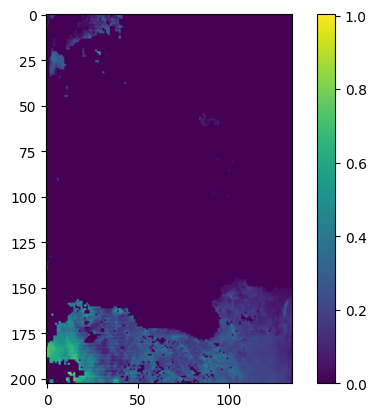

In [15]:
#Plot the AOD over the entire MODIS case
fig, ax=plt.subplots()
AOD[AOD<0]=0
AOD=AOD*0.001
cf=ax.imshow(AOD)
plt.colorbar(cf,ax=ax)

In [16]:
#Colocate the CERES locations with MODIS
CERES_lats=[29.00293,  29.036068, 29.07161,  29.021961, 28.939411, 28.953426, 28.933979,
 28.95956,  28.967682, 28.914364, 28.899063, 28.877792, 29.012066, 28.849411,
 28.807663, 28.801922, 28.8507,   28.90289,  28.739563, 28.735157, 28.645836,
 28.606316, 28.622211, 28.583473, 28.63139,  28.677444, 28.620312, 28.617031,
 28.588337, 28.561123, 28.571396, 28.712482]
CERES_lons=[15.517501, 15.501384, 15.072769, 15.333272, 15.443365, 15.345241, 15.616903,
 15.186105, 15.032485, 15.446713, 15.035253, 15.121785, 15.291064, 15.297291,
 15.558616, 15.078532, 15.142994, 15.336981, 15.40794,  15.251726, 15.331654,
 15.477041, 15.425315, 15.620312, 15.516856, 15.117836, 15.359198, 15.042234,
 15.12491,  15.221932, 15.079826, 15.048251]

for c in range(len(CERES_lons)):
    #convert between lat and lon to km
    CERESx=111.320*np.cos(np.deg2rad(CERES_lats[c]))*CERES_lons[c]
    CERESy=110.574*(CERES_lats[c])
    MODISx=111.320*np.cos(np.deg2rad(CERES_lats[c]))*Lon
    MODISy=110.574*Lat

    #find points within a 20km radius of the center of the CERES case
    dsquare=(MODISx-CERESx)**2+(MODISy-CERESy)**2
    in_distance_i=np.array(dsquare<=20**2) #(CERES footprint ~20km)
    print ("AODs inside of CERES pixel",AOD[in_distance_i])
    non_zero=AOD[in_distance_i]>0
    print ("CERES pixel number:",c, "Mean AOD in pixel:",AOD[in_distance_i][non_zero].mean())

AODs inside of CERES pixel [0.282 0.314 0.183 0.    0.41  0.235 0.2   0.201 0.298 0.289 0.    0.277]
CERES pixel number: 0 Mean AOD in pixel: 0.26890000000000003
AODs inside of CERES pixel [0.261 0.282 0.314 0.183 0.    0.41  0.235 0.2   0.201 0.298 0.289]
CERES pixel number: 1 Mean AOD in pixel: 0.26730000000000004
AODs inside of CERES pixel [0.    0.    0.345 0.44  0.    0.242 0.124 0.268 0.194 0.371]
CERES pixel number: 2 Mean AOD in pixel: 0.2834285714285715
AODs inside of CERES pixel [0.345 0.299 0.282 0.314 0.242 0.33  0.    0.41  0.194 0.197 0.201 0.298
 0.237 0.273]
CERES pixel number: 3 Mean AOD in pixel: 0.27861538461538465
AODs inside of CERES pixel [0.314 0.33  0.    0.41  0.235 0.197 0.201 0.298 0.289 0.273 0.277 0.319]
CERES pixel number: 4 Mean AOD in pixel: 0.2857272727272728
AODs inside of CERES pixel [0.282 0.33  0.    0.41  0.194 0.197 0.201 0.298 0.237 0.273 0.277]
CERES pixel number: 5 Mean AOD in pixel: 0.26990000000000003
AODs inside of CERES pixel [0.183 0.195 0